<a href="https://colab.research.google.com/github/shubhangviswanath/Thermo2DPINN/blob/main/DeepONet_TestCases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install deepxde -q
!python -m deepxde.backend.set_default_backend pytorch

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.
<frozen runpy>:128: RuntimeWarning: 'deepxde.backend.set_default_backend' found in sys.modules after import of package 'deepxde.backend', but prior to execution of 'deepxde.backend.set_default_backend'; this may result in unpredictable behaviour
Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [ ]:
import os
os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde

print(dde.backend.backend_name)

pytorch


In [ ]:
from deepxde.model import losses_module
##TEST CASE -1
import deepxde as dde
import torch
import numpy as np
import matplotlib.pyplot as plt
from deepxde.nn import DeepONetCartesianProd

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print("Using Device:", device)

##Antiderivative operator - G: u <-> s, where ds/dt = u(t), s(0)=0, t∈[0,1]
#Input function class: Gaussian Random Fields(GRF) with Radial Basis Function(RBF) Kernel - K(x,x') = exp(-y||x-x'||^2)

def run_test1(n_train=1000, n_test=200, m=100, p=40, epochs=8000, lr=1e-3):
    ##Parameters:n_train(Number of training input funcitons), n_test(Number of test input functions)
    ##m(Number of sensors - branch net input dimensions), p (number of basis functions(trunk/branch/output dimensions))

    print("\n" + "--"*45)
    print("Test Case-1:Learning Antiderivative operator using DeepONets:")
    print("--"*45)

    torch.manual_seed(45)
    np.random.seed(45)

    #Data Generation - sensors, fixed on [0,1]
    sensors = np.linspace(0, 1, m,dtype=np.float32)

    def grfsample_gen(n, sensors, length_scale=0.2):
        s64=sensors.astype(np.float64)
        q = len(s64)
        diff = s64[:, None] - s64[None, :]  #mxm Kernel matrix
        K = np.exp(-0.5*(diff**2)/(length_scale**2))
        K += 1e-7 * np.eye(q)
        L = np.linalg.cholesky(K)  ##
        xi = np.random.randn(m, n)   ##[0,1]
        return (L @ xi).T.astype(np.float32)

    def integ(u_vals, sensors):
      u_val64 = u_vals.astype(np.float64)
      s64= sensors.astype(np.float64)
        ##Integrating each row u
      return np.array([
        [np.trapezoid(u_val64[i, :j+1], s64[:j+1]) for j in range(len(s64))]
        for i in range(len(u_val64))
    ])

    u_train = grfsample_gen(n_train, sensors)
    s_train = integ(u_train, sensors)
    print(s_train.shape)

    u_test = grfsample_gen(n_test, sensors)
    s_test = integ(u_test, sensors)

    u_train = u_train.astype(np.float32)
    s_train = s_train.astype(np.float32)

    u_test  = u_test.astype(np.float32)
    s_test  = s_test.astype(np.float32)

    #Query Points - sensors
    y_train = sensors[:, None]
    y_test  = sensors[:, None]

    y_train = y_train.astype(np.float32)
    y_test  = y_test.astype(np.float32)

    #DeepXDE Dataset: u ->s
    x_train = (u_train, y_train)
    y_train_out = s_train

    x_test = (u_test, y_test)
    y_test_out = s_test

    data = dde.data.TripleCartesianProd(
        X_train=x_train,
        y_train=y_train_out,
        X_test=x_test,
        y_test=y_test_out,
    )

    ##Network Definition
    blayer = [m] + [128, 128, 128, p] ##Branch m->...p
    tlayer = [1] + [64, 64, 64, p]  ##Trunk

    net = dde.nn.DeepONetCartesianProd(
        layer_sizes_branch=blayer,
        layer_sizes_trunk=tlayer,
        activation="silu",
        kernel_initializer="Glorot normal",
    )

    model = dde.Model(data, net)
    model.compile("adam", lr=lr, metrics=["mean l2 relative error"])

    #TRAINING LOOP
    print(f"\nTraining for {epochs} epochs:")
    losshistory, train_state = model.train(iterations=epochs)

    #Model Evaluation
    s_pred = model.predict((u_test,y_test))
    rel_L2 = np.mean(np.linalg.norm(s_pred-s_test, axis=1) / np.linalg.norm(s_test, axis=1))##L2 error validation-relative
    print(f"\nTest Relative L2 error:{rel_L2:.4f} "
          f"({'PASS' if rel_L2<0.05 else 'retraining required!'})")

    #Plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for idx, ax in enumerate(axes):
        ax.plot(sensors, s_test[idx], "b--", lw=2, label="Ground Truth")
        ax.plot(sensors, s_pred[idx], "r--", lw=2, label="DeepONet Prediction")
        ax.set_title(f"Test Function #{idx+1}")
        ax.set_xlabel("t")
        ax.set_ylabel("s(t)")
        ax.legend(fontsize=9)
    fig.suptitle(f"Test Case#1 - Antiderivative|Rel L2 = {rel_L2:.4f}", fontsize=12)
    plt.tight_layout()
    plt.savefig("Case1.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("saved fig Case1.png successfully")

    return rel_L2

Using Device: cuda


In [ ]:
import deepxde as dde
import torch
import numpy as np
import matplotlib.pyplot as plt
from deepxde.nn import DeepONetCartesianProd

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print("Using Device:", device)

##Diffusion-Reaction operator - G: f ↦ u, where -D u''(x) + k u²(x) = f(x), x∈[0,1], u(0)=u(1)=0
#Input function class: Gaussian Random Fields(GRF) with Radial Basis Function(RBF) Kernel - K(x,x') = exp(-y||x-x'||^2)

def run_test2(n_train=2000, n_test=200, m=100, p=64, epochs=15000, lr=5e-4, D=0.01, k=0.01):
    ##Parameters: n_train(Number of training input functions), n_test(Number of test input functions)
    ##m(Number of sensors - branch net input dimensions), p(number of basis functions(trunk/branch output dimensions))
    ##D(Diffusion coefficient), k(Reaction coefficient)

    print("\n" + "--"*45)
    print("Test Case-2: Learning Diffusion-Reaction operator using DeepONets:")
    print(f"   -D u''(x) + k u²(x) = f(x),  D={D}, k={k}")
    print("--"*45)

    torch.manual_seed(45)
    np.random.seed(45)

    #Data Generation - sensors, fixed on [0,1]
    sensors = np.linspace(0, 1, m, dtype=np.float32)

    def grfsample_gen(n, sensors, length_scale=0.2):
        s64 = sensors.astype(np.float64)
        q = len(s64)
        diff = s64[:, None] - s64[None, :]  #mxm Kernel matrix
        K = np.exp(-0.5*(diff**2)/(length_scale**2))
        K += 1e-4 * np.eye(q)
        L = np.linalg.cholesky(K)  ##
        xi = np.random.randn(q, n)   ##[0,1]
        return (L @ xi).T.astype(np.float32)

    def solve_dr(f_vals, D=D, k=k, n_iter=50, tol=1e-10):
        ##Solve -D u'' + k u^2 = f on [0,1] with u(0)=u(1)=0
        ##via Newton's method on the interior nodes
        ##f_vals: (N_grid,) array - Returns u: (N_grid,) with BCs enforced
        f64 = f_vals.astype(np.float64)
        N = len(f64)
        h = 1.0 / (N - 1)
        #Interior indices: 1..N-2
        n_int = N - 2
        f_int = f64[1:-1]

        #Laplacian (interior, Dirichlet BCs → u[0]=u[N-1]=0 drops out)
        diag = -2.0 * np.ones(n_int)
        off  =  1.0 * np.ones(n_int - 1)
        L = (np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)) / h**2

        u_int = np.zeros(n_int)
        for _ in range(n_iter):
            #Residual: -D L u + k u² - f = 0
            F = -D * (L @ u_int) + k * u_int**2 - f_int
            #Jacobian: -D L + 2k diag(u)
            J = -D * L + 2 * k * np.diag(u_int)
            delta = np.linalg.solve(J, -F)
            u_int = u_int + delta
            if np.linalg.norm(delta) < tol:
                break

        u = np.zeros(N)
        u[1:-1] = u_int
        return u.astype(np.float32)

    print("Generating training data (may take ~1 min on CPU) ...")
    f_train_raw =  grfsample_gen(n_train,sensors)
    f_train = np.abs(f_train_raw) +0.1
    u_train = np.array([solve_dr(f_train[i]) for i in range(n_train)])
    print(f"  f_train: {f_train.shape}, u_train: {u_train.shape}")


    print("Generating test data ...")
    f_test_raw = grfsample_gen(n_test, sensors)
    f_test  = np.abs(f_test_raw)+0.1
    u_test  = np.array([solve_dr(f_test[i]) for i in range(n_test)])

    f_train = f_train.astype(np.float32)
    u_train = u_train.astype(np.float32)

     #Global Data Scaling

    u_max = np.max(np.abs(u_train))
    u_train_scaled = u_train / u_max
    u_test_scaled  = u_test  / u_max

    f_train = f_train_raw.astype(np.float32)

    f_test  = f_test.astype(np.float32)
    u_test  = u_test.astype(np.float32)

    #Query Points - sensors
    y_train = sensors[:, None].astype(np.float32)
    y_test  = sensors[:, None].astype(np.float32)

    #DeepXDE Dataset: f -> u
    x_train = (f_train, y_train)
    u_train_out = u_train_scaled

    x_test = (f_test, y_test)
    u_test_out = u_test_scaled

    data = dde.data.TripleCartesianProd(
        X_train=x_train,
        y_train=u_train_out,
        X_test=x_test,
        y_test=u_test_out,
    )

    ##Network Definition
    blayer = [m] + [256, 256, 256, p]  ##Branch m->...->p
    tlayer = [1] + [256, 256, 256, p]  ##Trunk

    net = dde.nn.DeepONetCartesianProd(
        layer_sizes_branch=blayer,
        layer_sizes_trunk=tlayer,
        activation="silu",
        kernel_initializer="Glorot normal",
    )

    model = dde.Model(data, net)
    model.compile("adam", lr=lr, metrics=["l2 relative error"])

    #TRAINING LOOP - Phase 1: Adam
    epochs_adam = 14000
    print(f"\nPhase 1: Adam, {epochs_adam} iterations:")
    losshistory, train_state = model.train(iterations=epochs_adam)

    #TRAINING LOOP - Phase 2: L-BFGS refinement
    epochs_lbfgs = epochs - epochs_adam
    print("Phase 2: L-BFGS refinement:")
    dde.optimizers.config.set_LBFGS_options(maxiter=1000)
    model.compile("L-BFGS", metrics=["l2 relative error"])
    losshistory, train_state = model.train(iterations=epochs_lbfgs)

    #Model Evaluation
    u_pred_scaled = model.predict((f_test, y_test))
    u_pred = u_pred_scaled * u_max
    rel_L2 = np.mean(np.linalg.norm(u_pred - u_test, axis=1) / np.linalg.norm(u_test + 1e-12, axis=1))  ##L2 error validation-relative
    print(f"\nTest Relative L2 error:{rel_L2:.4f} "
          f"({'PASS' if rel_L2<0.05 else 'retraining required!'})")

    #Plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for idx, ax in enumerate(axes):
        ax.plot(sensors, u_test[idx], "b--", lw=2, label="Ground Truth")
        ax.plot(sensors, u_pred[idx], "r--", lw=2, label="DeepONet Prediction")
        ax.fill_between(sensors,
                        u_test[idx] - np.abs(u_pred[idx] - u_test[idx]),
                        u_test[idx] + np.abs(u_pred[idx] - u_test[idx]),
                        alpha=0.15, color="red", label="|error|")
        ax.set_title(f"Test Function #{idx+1}")
        ax.set_xlabel("x")
        ax.set_ylabel("u(x)")
        ax.legend(fontsize=9)
    fig.suptitle(f"Test Case#2 - Diffusion-Reaction|Rel L2 = {rel_L2:.4f}", fontsize=12)
    plt.tight_layout()
    plt.savefig("Case2.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("saved fig Case2.png successfully")

    return rel_L2

Using Device: cuda



------------------------------------------------------------------------------------------
Test Case-2: Learning Diffusion-Reaction operator using DeepONets:
   -D u''(x) + k u²(x) = f(x),  D=0.0001, k=0.01
------------------------------------------------------------------------------------------
Generating training data (may take ~1 min on CPU) ...
  f_train: (2000, 100), u_train: (2000, 100)
Generating test data ...
Compiling model...
'compile' took 0.000446 s


Phase 1: Adam, 14000 iterations:
Training model...

Step      Train loss    Test loss     Test metric   
0         [2.02e-01]    [1.95e-01]    [9.98e-01]    
1000      [1.09e-02]    [1.20e-02]    [2.48e-01]    
2000      [8.48e-03]    [9.34e-03]    [2.18e-01]    
3000      [4.73e-03]    [5.84e-03]    [1.72e-01]    
4000      [4.68e-03]    [5.77e-03]    [1.71e-01]    
5000      [3.57e-03]    [4.61e-03]    [1.53e-01]    
6000      [2.98e-03]    [3.93e-03]    [1.42e-01]    
7000      [1.92e-03]    [2.86e-03]    [1.21e-01]    
8

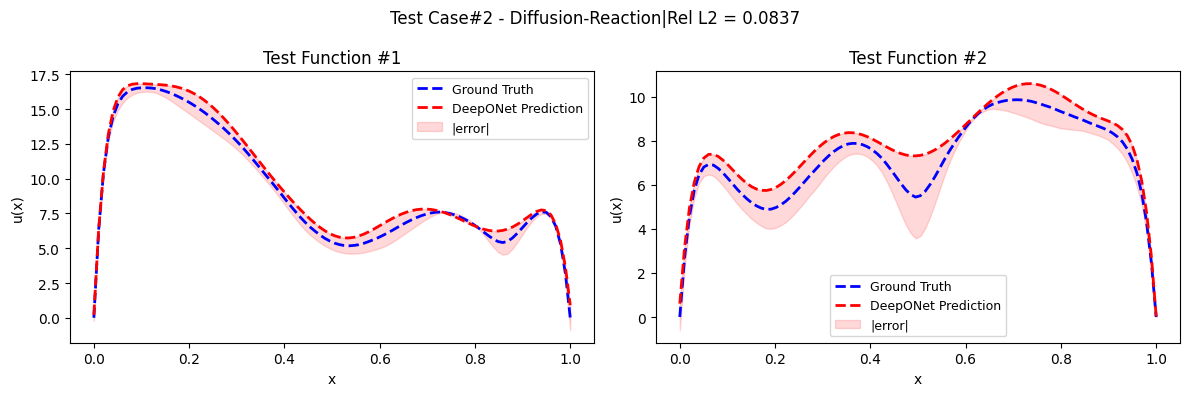

saved fig Case2.png successfully

SUMMARY
 TC2 Diffusion Reaction:      Rel L2 = 0.0837

Expected (from Lu et al. 2021):
  TC2: < 0.02   (harder; nonlinear operator)


In [ ]:
if __name__=="__main__":
  #c1 = run_test1(n_train=1000,n_test=200,m=100,p=40,epochs=15000,lr=1e-3)
  c2=run_test2(n_train=2000,n_test=200,m=100,p=64,epochs=4500,lr=5e-4,D=0.0001,k=0.01)
  print("\n" + "="*60)
  print("SUMMARY")
  print("="*60)
  #print(f"  TC1 Antiderivative:       Rel L2 ={c1:.4f}")
  print(f" TC2 Diffusion Reaction:      Rel L2 = {c2:.4f}")
  print("\nExpected (from Lu et al. 2021):")
  #print("  TC1: < 0.001  (very easy; linear operator)")
  print("  TC2: < 0.02   (harder; nonlinear operator)")


In [ ]:
"""import deepxde as dde
print("Version:",dde.__version__)"""

'import deepxde as dde\nprint("Version:",dde.__version__)'